# Linear Regression Model

This notebook trains a **Linear Regression** model using the common preprocessed dataset.

**Prerequisite:** Run `00_common_preprocessing.ipynb` first to generate the preprocessed data.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("Base libraries loaded successfully")
print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load Common Preprocessed Data

Linear Regression uses **scaled** features (StandardScaler) for better performance.

In [2]:
# Load preprocessed data (SCALED for Linear Regression)
data_dir = '../data/preprocessed'

X_train = pd.read_csv(f'{data_dir}/X_train_scaled.csv')
X_test = pd.read_csv(f'{data_dir}/X_test_scaled.csv')
y_train = pd.read_csv(f'{data_dir}/y_train.csv').squeeze()
y_test = pd.read_csv(f'{data_dir}/y_test.csv').squeeze()

# Also load unscaled for reference
X_train_unscaled = pd.read_csv(f'{data_dir}/X_train.csv')
feature_names = joblib.load(f'{data_dir}/feature_names.pkl')

print("=" * 50)
print("COMMON PREPROCESSED DATA LOADED")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")
print(f"Feature names: {feature_names}")
print(f"\nUsing SCALED data for Linear Regression.")

COMMON PREPROCESSED DATA LOADED
Training set: 5285 samples
Testing set:  1322 samples
Features: 19
Feature names: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Using SCALED data for Linear Regression.


## 2. Multicollinearity Check (VIF)

In [3]:
# Check for Multicollinearity using Variance Inflation Factor (VIF)
vif_data = pd.DataFrame()
vif_data['Feature'] = feature_names
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("Variance Inflation Factor (VIF) Analysis:")
print("=" * 45)
print(vif_data.to_string(index=False))
print("\nInterpretation:")
print("- VIF = 1: No correlation")
print("- VIF < 5: Moderate (acceptable)")
print("- VIF > 10: High multicollinearity (problematic)")

Variance Inflation Factor (VIF) Analysis:
                   Feature      VIF
  Parental_Education_Level 1.006135
         Physical_Activity 1.006129
           Previous_Scores 1.005153
             Family_Income 1.004786
                Attendance 1.004734
          Motivation_Level 1.004495
     Learning_Disabilities 1.004017
       Access_to_Resources 1.003822
           Internet_Access 1.003668
           Teacher_Quality 1.003645
               Sleep_Hours 1.003099
             Hours_Studied 1.002965
            Peer_Influence 1.002885
        Distance_from_Home 1.002801
      Parental_Involvement 1.002625
               School_Type 1.002266
                    Gender 1.001834
         Tutoring_Sessions 1.001698
Extracurricular_Activities 1.001276

Interpretation:
- VIF = 1: No correlation
- VIF < 5: Moderate (acceptable)
- VIF > 10: High multicollinearity (problematic)


## 3. Train Linear Regression Model

In [4]:
# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## 4. Cross-Validation

In [5]:
# Cross-Validation for more robust evaluation (5-fold)
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

cv_scores_r2 = cross_val_score(lr_model, X_all, y_all, cv=5, scoring='r2')
cv_scores_mae = cross_val_score(lr_model, X_all, y_all, cv=5, scoring='neg_mean_absolute_error')

print("===== 5-Fold Cross-Validation Results =====")
print(f"\nR² Scores per fold: {cv_scores_r2.round(4)}")
print(f"Mean R² Score: {cv_scores_r2.mean():.4f} (+/- {cv_scores_r2.std() * 2:.4f})")
print(f"\nMAE Scores per fold: {(-cv_scores_mae).round(4)}")
print(f"Mean MAE: {(-cv_scores_mae).mean():.4f} (+/- {cv_scores_mae.std() * 2:.4f})")

===== 5-Fold Cross-Validation Results =====

R² Scores per fold: [0.6608 0.8112 0.6275 0.5128 0.6887]
Mean R² Score: 0.6602 (+/- 0.1927)

MAE Scores per fold: [1.0499 0.9587 1.1499 1.1514 1.0162]
Mean MAE: 1.0652 (+/- 0.1512)


## 5. Model Coefficients

In [6]:
# View model coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print("Model Coefficients:")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_model.intercept_:.4f}")

Model Coefficients:
                   Feature  Coefficient
                Attendance     2.278447
             Hours_Studied     1.729651
           Previous_Scores     0.693226
         Tutoring_Sessions     0.619609
            Peer_Influence     0.404641
        Distance_from_Home     0.314200
Extracurricular_Activities     0.278966
           Internet_Access     0.259460
         Physical_Activity     0.178424
  Parental_Education_Level     0.124040
                    Gender    -0.009275
               School_Type    -0.015342
               Sleep_Hours    -0.042515
          Motivation_Level    -0.120481
             Family_Income    -0.123489
           Teacher_Quality    -0.213377
     Learning_Disabilities    -0.273584
       Access_to_Resources    -0.352155
      Parental_Involvement    -0.386744

Intercept: 67.2151


## 6. Evaluate the Model

In [7]:
# Make predictions
y_pred = lr_model.predict(X_test)

# Calculate metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("===== Linear Regression Results =====")
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Root Mean Squared Error   : {rmse:.4f}")
print(f"R² Score                  : {r2:.4f}")

===== Linear Regression Results =====
Mean Absolute Error (MAE) : 1.0155
Root Mean Squared Error   : 2.0974
R² Score                  : 0.6888


## 7. Visualizations

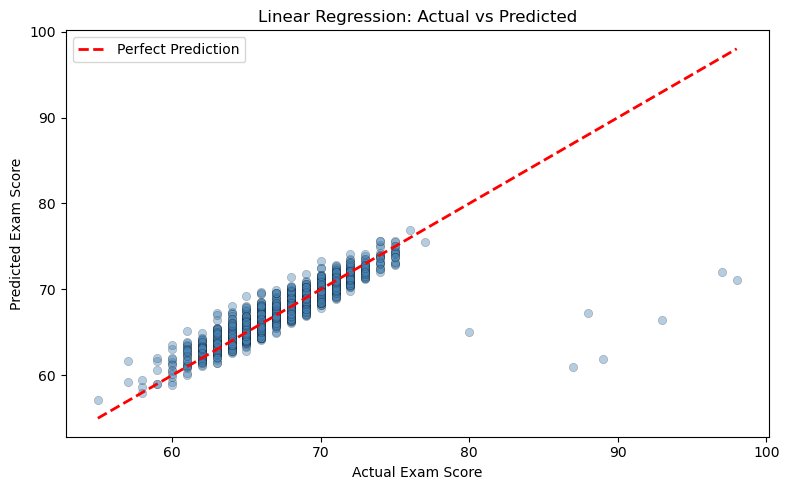

In [8]:
# Plot: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

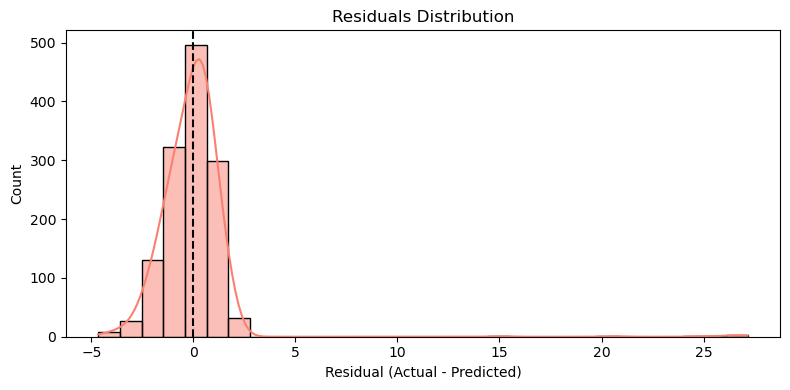

In [9]:
# Plot: Residuals distribution
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=30, kde=True, color='salmon')
plt.axvline(0, color='black', linestyle='--')
plt.title('Residuals Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

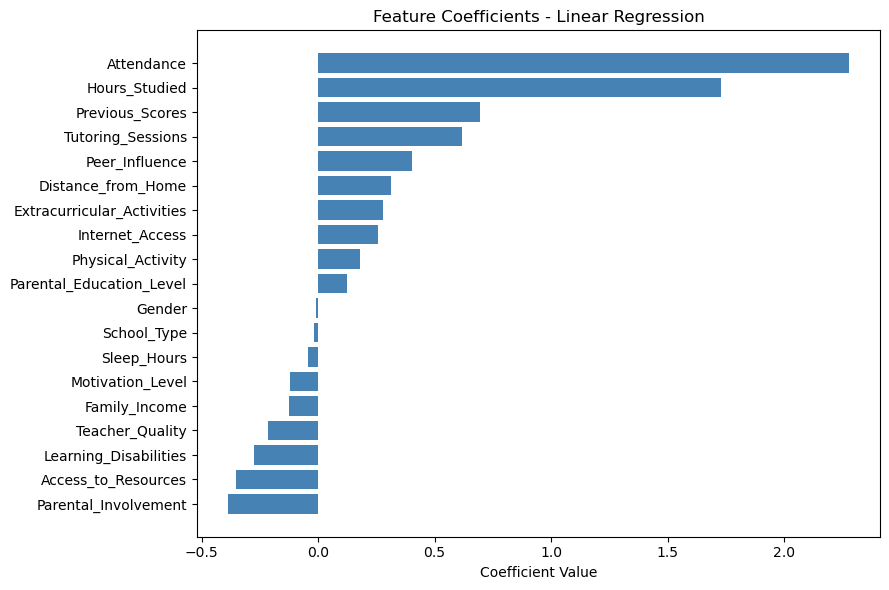

In [10]:
# Plot: Feature Coefficients
coef_sorted = coef_df.sort_values('Coefficient', ascending=True)
plt.figure(figsize=(9, 6))
plt.barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color='steelblue')
plt.title('Feature Coefficients - Linear Regression')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 8. Save the Model

In [11]:
# Save model
os.makedirs('../models', exist_ok=True)
joblib.dump(lr_model, '../models/linear_regression_model.pkl')

# Save metrics for comparison
metrics = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
joblib.dump(metrics, '../models/linear_regression_metrics.pkl')

print("Model saved to ../models/linear_regression_model.pkl")
print(f"Metrics saved: {metrics}")

Model saved to ../models/linear_regression_model.pkl
Metrics saved: {'MAE': 1.0155490830845972, 'RMSE': np.float64(2.0974450026570315), 'R2': 0.6887688020307756}
